In [163]:
import pandas
import os

In [164]:
BLACK = '\033[30m'
RED = '\033[31m'
GREEN = '\033[32m'
YELLOW = '\033[33m' # orange on some systems
BLUE = '\033[34m'
MAGENTA = '\033[35m'
CYAN = '\033[36m'
LIGHT_GRAY = '\033[37m'
DARK_GRAY = '\033[90m'
BRIGHT_RED = '\033[91m'
BRIGHT_GREEN = '\033[92m'
BRIGHT_YELLOW = '\033[93m'
BRIGHT_BLUE = '\033[94m'
BRIGHT_MAGENTA = '\033[95m'
BRIGHT_CYAN = '\033[96m'
RESET = '\033[0m' # called to return to standard terminal text color

def colored_text(color, txt):
    return color + str(txt) + RESET

In [165]:
datasets_path = "data"
years = [2019,2020, 2021, 2022, 2023, 2024]

df_lieux = []

for year in years:
    df_lieux_year = pandas.read_csv(os.path.join(datasets_path, str(year), f"lieux-{year}.csv"), encoding="utf-8", sep = ";", dtype=str)
    df_lieux.append(df_lieux_year)

df_lieux = pandas.concat(df_lieux)
df_lieux

,Num_Acc,catr,voie,v1,v2,circ,nbv,vosp,prof,pr,pr1,plan,lartpc,larrout,surf,infra,situ,vma
0,201900000001,1,3,0,NaN,3,10,0,1,6,900,2,NaN,NaN,1,2,1,70
1,201900000002,1,1,0,NaN,1,2,0,4,3,845,2,NaN,NaN,1,0,1,70
2,201900000003,1,86,0,NaN,3,8,0,1,10,500,3,NaN,NaN,1,0,1,90
3,201900000004,1,4,0,NaN,3,5,0,1,2,299,1,NaN,NaN,1,0,1,90
4,201900000005,1,86,0,INT,1,3,0,1,41,0,3,NaN,NaN,1,2,1,90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70243,202400054398,3,NaN,-1,NaN,1,1,-1,1,-1,-1,1,NaN,-1,2,5,4,-1
70244,202400054399,3,RUE PIERRE GAUDIN,0,NaN,1,1,2,1,0,0,2,NaN,-1,1,0,1,30
70245,202400054400,2,12,0,NaN,1,2,0,2,31,1 000,1,NaN,10,1,0,1,110
70246,202400054401,3,JEAN JAURES (BOULEVARD) 63/215 - 70/208,0,NaN,2,3,0,1,0,0,1,NaN,"10,5",1,0,1,50


In [166]:
column_names_to_int = ['Num_Acc', 'catr', 'v1', 'circ', 'nbv', 'vosp', 'prof', 'pr', 'pr1', 'plan', 'lartpc', 'larrout', 'surf',
       'infra', 'situ', 'vma']

df_lieux[column_names_to_int] = df_lieux[column_names_to_int].apply(
    lambda col: pandas.to_numeric(
        col.astype(str).str.extract(r'(-?\d+)')[0],
        errors="coerce"
    )
)

In [167]:
df_lieux.replace(-1, pandas.NA, inplace=True)

for col in df_lieux.columns:
    prop = df_lieux[col].isna().sum() / len(df_lieux)
    print(f"For {colored_text(MAGENTA, col)} proportion missing: {prop * 100:.2f}%")

For Num_Acc proportion missing: 0.00%
For catr proportion missing: 0.00%
For voie proportion missing: 13.67%
For v1 proportion missing: 20.02%
For v2 proportion missing: 91.91%
For circ proportion missing: 6.00%
For nbv proportion missing: 2.97%
For vosp proportion missing: 2.53%
For prof proportion missing: 0.08%
For pr proportion missing: 15.90%
For pr1 proportion missing: 15.97%
For plan proportion missing: 0.07%
For lartpc proportion missing: 99.84%
For larrout proportion missing: 86.00%
For surf proportion missing: 0.09%
For infra proportion missing: 1.10%
For situ proportion missing: 0.11%
For vma proportion missing: 3.23%


In [168]:
df_lieux.replace(-1, pandas.NA, inplace=True)

for col in df_lieux.columns:
    prop = df_lieux[col].isna().sum() / len(df_lieux)
    if (prop * 100 > 10):
        print(f"For {colored_text(MAGENTA, col)} proportion missing: {prop * 100:.2f}%")

For voie proportion missing: 13.67%
For v1 proportion missing: 20.02%
For v2 proportion missing: 91.91%
For pr proportion missing: 15.90%
For pr1 proportion missing: 15.97%
For lartpc proportion missing: 99.84%
For larrout proportion missing: 86.00%


In [169]:
# First we are dropping features that we are not going to use
df_lieux.drop(columns = ['voie', 'v1', 'v2', 'pr', 'pr1', 'lartpc', 'larrout'], inplace = True)

In [170]:
# Removing rows with missing values
df_lieux = df_lieux.dropna()

# And converting to int
column_names_to_int = ['catr', 'circ', 'nbv', 'vosp', 'prof', 'plan', 'surf',
       'infra', 'situ', 'vma']

df_lieux[column_names_to_int] = df_lieux[column_names_to_int].astype("int64")

In [171]:
df_lieux["vma"].describe()

count    318820.000000
mean         59.604165
std          23.571162
min           0.000000
25%          50.000000
50%          50.000000
75%          80.000000
max         901.000000
Name: vma, dtype: float64

<Axes: xlabel='vma', ylabel='Count'>

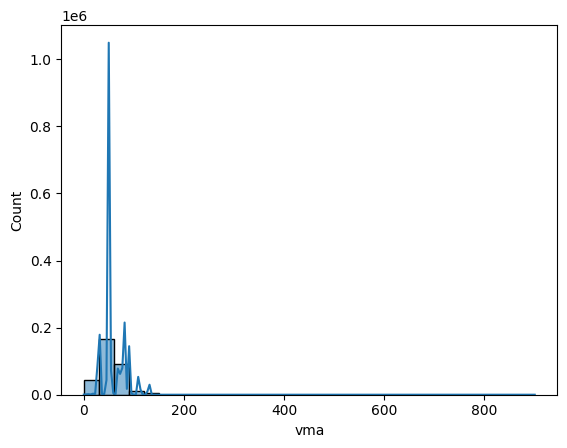

In [172]:
import seaborn as sns
sns.histplot(df_lieux["vma"], bins=30, kde=True)

In [173]:
valid_limits = [5,10,15,20,30,50,70,80,90,110,130]
percentage = 1 - (len(df_lieux['vma'][df_lieux['vma'].isin(valid_limits)]) / len(df_lieux['vma']))
print(f"Proportion of speed limit outside valid limits: {percentage * 100 :0.2f}%")

Proportion of speed limit outside valid limits: 0.55%


In [174]:
df_lieux['vma'] = df_lieux['vma'].where(df_lieux['vma'].isin(valid_limits), None)

In [175]:
df_lieux['vma'].isna().sum()

np.int64(1762)

In [176]:
df_lieux = df_lieux.dropna()
df_lieux['vma'] = df_lieux['vma'].astype("int64")

In [177]:
df_lieux["nbv"].describe()

count    317058.000000
mean          2.363549
std           1.273385
min           0.000000
25%           2.000000
50%           2.000000
75%           2.000000
max          12.000000
Name: nbv, dtype: float64

In [178]:
nvb_val = df_lieux["nbv"].unique()
nvb_val.sort()
nvb_val

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12])

In [179]:
df_lieux["nbv"].value_counts()

nbv
2     200190
4      34886
1      34168
3      24577
6       7501
0       7138
5       4508
8       2260
7        790
10       522
9        316
12       117
11        85
Name: count, dtype: int64

In [180]:
percentage_empty = len(df_lieux['nbv'][df_lieux['nbv'] == 0]) / len(df_lieux['nbv'])
print(f"Proportion of empty nbv: {percentage_empty * 100 :0.2f}%")

Proportion of empty nbv: 2.25%


9 (316)
10 (522)
11 (85)
12 (117)
👉 These are:
extremely rare (~0.4% total)
borderline unrealistic in most real-world French roads
Even something like:
10–12 lanes total = very large infrastructure
possible in theory, but unlikely at this frequency and distribution
⚠️ This strongly suggests:
either data noise
or inconsistent interpretation (e.g., counting lanes incorrectly)

In [181]:
valid_nbv = [i for i in range(1, 9)]
percentage = 1 - (len(df_lieux['nbv'][df_lieux['nbv'].isin(valid_nbv)]) / len(df_lieux['nbv']))
print(f"Proportion of nbv with extremely large values: {(percentage - percentage_empty) * 100:0.2f}%")

Proportion of nbv with extremely large values: 0.33%


In [182]:
df_lieux['nbv'] = df_lieux['nbv'].where(df_lieux['nbv'].isin(valid_nbv), None)
df_lieux = df_lieux.dropna()
df_lieux['nbv'] = df_lieux['nbv'].astype("int64")

In [183]:
features = column_names_to_int[:]
numerical_features = ["vma", "nbv"]
categorical_features = list(set(features) - set(numerical_features))

In [184]:
# We need to load usagers, because it conatains our target column
df_usagers = pandas.read_csv("df_usagers_clean.csv")

df_lieux_with_target = df_lieux.merge(
    df_usagers[['Num_Acc', 'grav_bin']],
    on='Num_Acc',
    how='left'
)

target = "grav_bin"

In [185]:
df_lieux_with_target = df_lieux_with_target.dropna()

In [186]:
df_lieux_analyse = df_lieux_with_target.copy() 

mapping = {
    1: "Motorway",  
    2: "National road",  
    3: "Departmental road",  
    4: "Municipal road",  
    5: "Outside public road network",  
    6: "Public parking area",  
    7: "Urban metropolitan roads",  
    9: "Other"
}
df_lieux_analyse["catr"] = df_lieux_analyse["catr"].replace(mapping)

mapping = {
    1: "One-way",
    2: "Two-way",
    3: "Divided road",
    4: "Variable lanes"
}
df_lieux_analyse["circ"] = df_lieux_analyse["circ"].replace(mapping)

# nbv - ok

mapping = {
    0: "Not applicable",
    1: "Cycle path",
    2: "Cycle lane",
    3: "Reserved lane"
}
df_lieux_analyse["vosp"] = df_lieux_analyse["vosp"].replace(mapping)

mapping = {
    1: "Flat",  
    2: "Slope",  
    3: "Hilltop",  
    4: "Bottom of hill"
}
df_lieux_analyse["prof"] = df_lieux_analyse["prof"].replace(mapping)

mapping = {
    1: "Straight section",  
    2: "Left curve",  
    3: "Right curve", 
    4: "S-shaped curve"
}
df_lieux_analyse["plan"] = df_lieux_analyse["plan"].replace(mapping)

mapping = {
    1: "Normal",   
    2: "Wet",   
    3: "Puddles",   
    4: "Flooded",   
    5: "Snow-covered",   
    6: "Mud",  
    7: "Icy",   
    8: "Oil or other slippery substance",   
    9: "Other"
}
df_lieux_analyse["surf"] = df_lieux_analyse["surf"].replace(mapping)

mapping = {
    0: "None",   
    1: "Tunnel",  
    2: "Bridge",  
    3: "Ramp or interchange",  
    4: "Railway crossing",  
    5: "Designed intersection",  
    6: "Pedestrian area",  
    7: "Toll area",  
    8: "Roadworks",  
    9: "Other"
}
df_lieux_analyse["infra"] = df_lieux_analyse["infra"].replace(mapping)

mapping = {
    0: "None",
    1: "On roadway",  
    2: "On emergency lane",  
    3: "On shoulder",  
    4: "On sidewalk",  
    5: "On cycle path",  
    6: "On other special lane",  
    8: "Other"
}
df_lieux_analyse["situ"] = df_lieux_analyse["situ"].replace(mapping)

# vma - ok

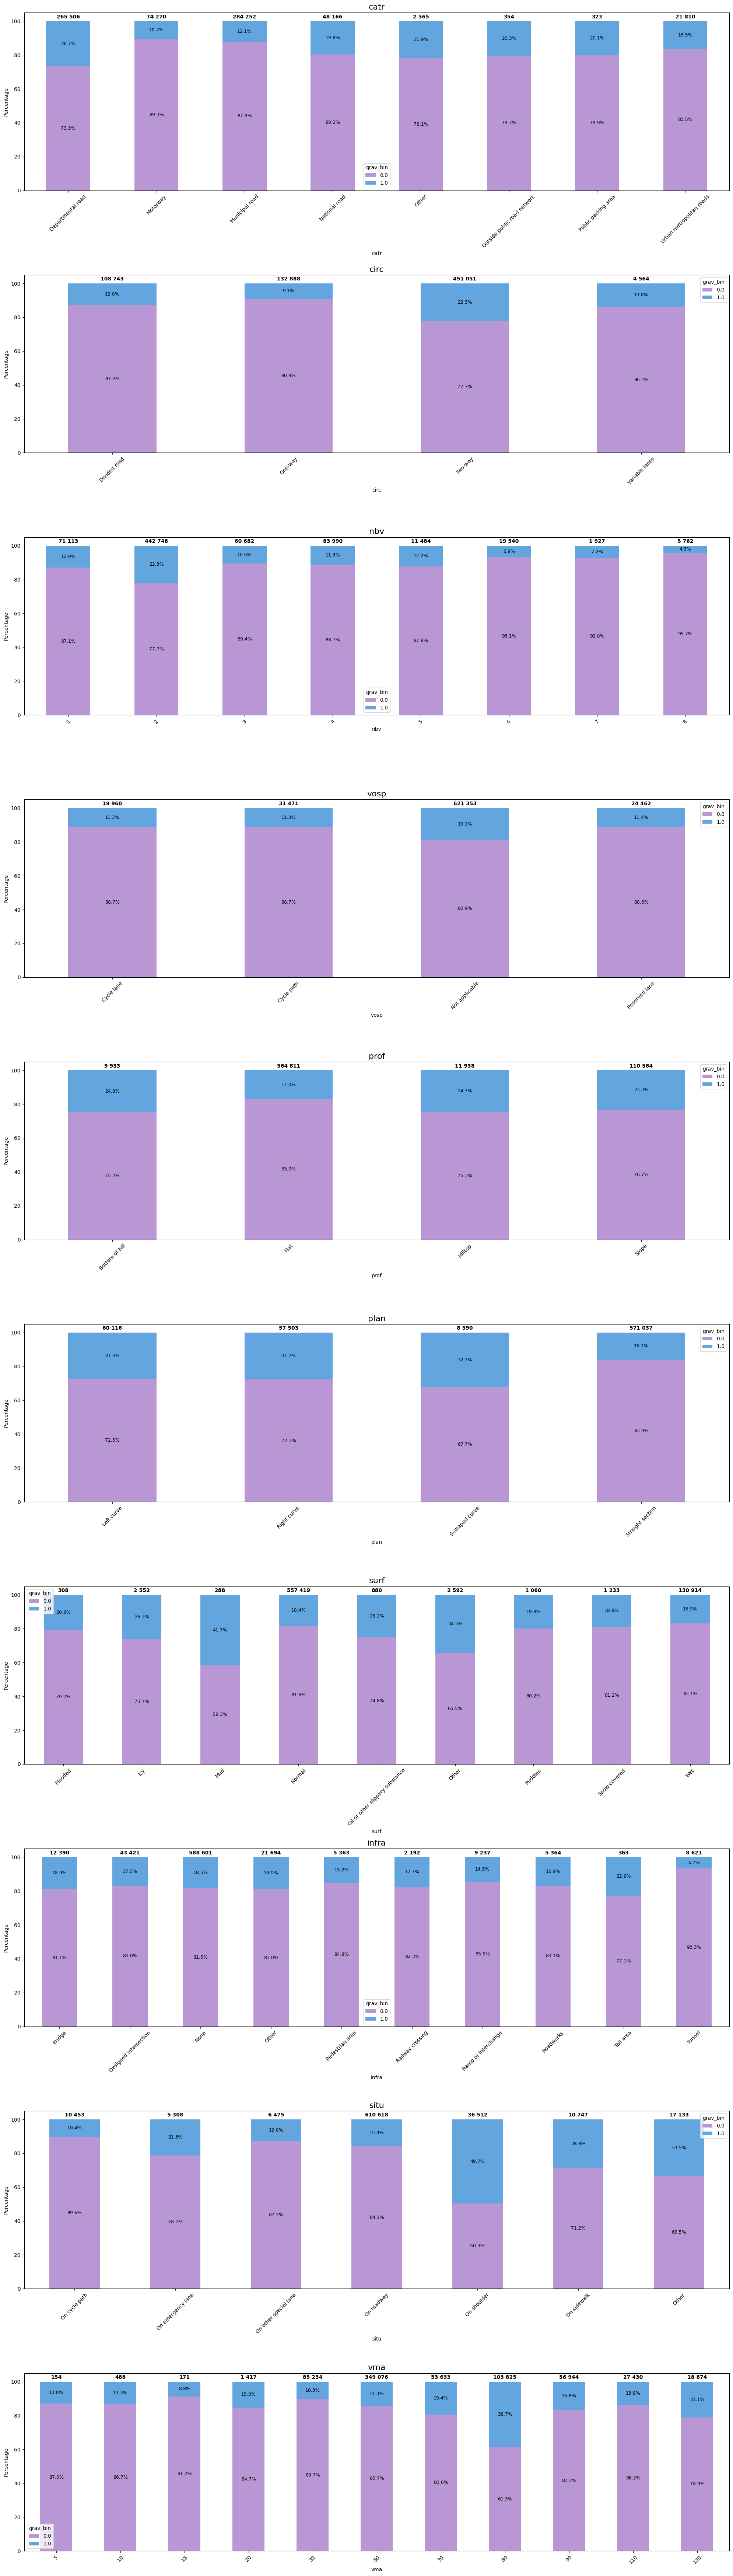

In [187]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(len(features), 1, figsize=(20, 6*len(features) + 10))

df_lieux_analyse = df_lieux_analyse.reset_index(drop=True)

for i, feature in enumerate(features):
    ct = pandas.crosstab(
        df_lieux_analyse[feature],
        df_lieux_analyse[target],
        normalize="index"
    ) * 100

    counts = df_lieux_analyse[feature].value_counts().sort_index()

    # Plot
    ct.plot(kind="bar", stacked=True, ax=ax[i], color=["#B997D4", "#62A5DF"])

    # Add % labels inside bars
    for j, category in enumerate(ct.index):
        cumulative = 0
        for k, col in enumerate(ct.columns):
            value = ct.loc[category, col]
            if value > 3:  # avoid clutter for tiny values
                ax[i].text(
                    j,
                    cumulative + value / 2,
                    f"{value:.1f}%",
                    ha="center",
                    va="center",
                    fontsize=9,
                    color="black"
                )
            cumulative += value

    # Add total count above bars
    for j, category in enumerate(ct.index):
        ax[i].text(
            j,
            101,  # slightly above 100%
            f"{counts[category]:,}".replace(",", " "),
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold"
        )

    ax[i].set_title(feature, fontsize=16)
    ax[i].tick_params(axis='x', rotation=45)
    ax[i].set_ylabel("Percentage")

plt.tight_layout()

In [190]:
import pandas as pd

output_lines = []

for feature in features:
    # Count per class
    counts = df_lieux_analyse.groupby(feature)[target].value_counts().unstack(fill_value=0)
    
    # Proportions (in %)
    proportions = counts.div(counts.sum(axis=1), axis=0) * 100

    # Ensure column order (adapt if needed)
    # Assuming: 0 = not severe, 1 = severe
    for i, category in enumerate(counts.index):
        count = counts.loc[category].sum()
        not_severe = proportions.loc[category].get(0, 0)
        severe = proportions.loc[category].get(1, 0)

        if i == 0:
            line = f"\\texttt{{{feature}}} & {category} & {count:,} & {not_severe:.1f} & {severe:.1f} \\\\"
        else:
            line = f" & {category} & {count:,} & {not_severe:.1f} & {severe:.1f} \\\\"

        # Replace commas for LaTeX formatting (French style spacing)
        line = line.replace(",", " ")

        output_lines.append(line)

    output_lines.append("\\hline")

# Print result
print("\n".join(output_lines))

\texttt{catr} & Departmental road & 265 506 & 73.3 & 26.7 \\
 & Motorway & 74 270 & 89.3 & 10.7 \\
 & Municipal road & 284 252 & 87.9 & 12.1 \\
 & National road & 48 166 & 80.2 & 19.8 \\
 & Other & 2 565 & 78.1 & 21.9 \\
 & Outside public road network & 354 & 79.7 & 20.3 \\
 & Public parking area & 323 & 79.9 & 20.1 \\
 & Urban metropolitan roads & 21 810 & 83.5 & 16.5 \\
\hline
\texttt{circ} & Divided road & 108 743 & 87.2 & 12.8 \\
 & One-way & 132 888 & 90.9 & 9.1 \\
 & Two-way & 451 051 & 77.7 & 22.3 \\
 & Variable lanes & 4 564 & 86.2 & 13.8 \\
\hline
\texttt{nbv} & 1 & 71 113 & 87.1 & 12.9 \\
 & 2 & 442 748 & 77.7 & 22.3 \\
 & 3 & 60 682 & 89.4 & 10.6 \\
 & 4 & 83 990 & 88.7 & 11.3 \\
 & 5 & 11 484 & 87.8 & 12.2 \\
 & 6 & 19 540 & 93.1 & 6.9 \\
 & 7 & 1 927 & 92.8 & 7.2 \\
 & 8 & 5 762 & 95.7 & 4.3 \\
\hline
\texttt{vosp} & Cycle lane & 19 960 & 88.7 & 11.3 \\
 & Cycle path & 31 471 & 88.7 & 11.3 \\
 & Not applicable & 621 353 & 80.9 & 19.1 \\
 & Reserved lane & 24 462 & 88.6 & 1

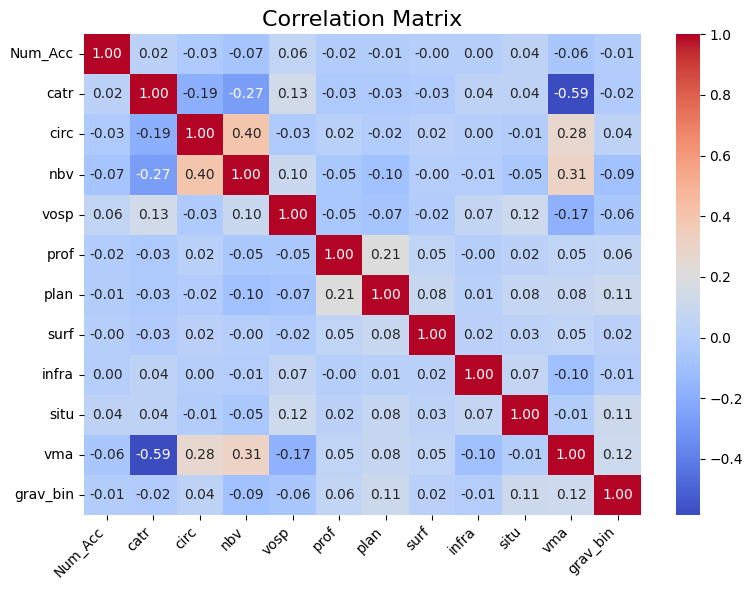

In [191]:
import seaborn as sns

plt.figure(figsize=(8, 6))

sns.heatmap(
    df_lieux_with_target.corr(),
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    annot_kws={"size": 10}
)

plt.title("Correlation Matrix", fontsize=16)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [192]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [193]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier()
}

pipelines = {}

for name, model in models.items():
    pipelines[name] = Pipeline([
        ("preprocessing", preprocessor),
        ("model", model)
    ])

In [194]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X = df_lieux_with_target[categorical_features + numerical_features]
y = df_lieux_with_target[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

for name, pipeline in pipelines.items():
    pipeline.fit(X_train, y_train)

In [195]:
for name, pipe in pipelines.items():
    y_pred = pipe.predict(X_test)
    print("\n", name)
    print("Accuracy:", accuracy_score(y_test, y_pred))


 Logistic Regression
Accuracy: 0.8225959125134457

 Decision Tree
Accuracy: 0.8193617784152026

 Random Forest
Accuracy: 0.8190462531373252

 Gradient Boosting
Accuracy: 0.8232341340982431


AUC of Logistic Regression: 0.715
AUC of Decision Tree: 0.699
AUC of Random Forest: 0.708
AUC of Gradient Boosting: 0.721


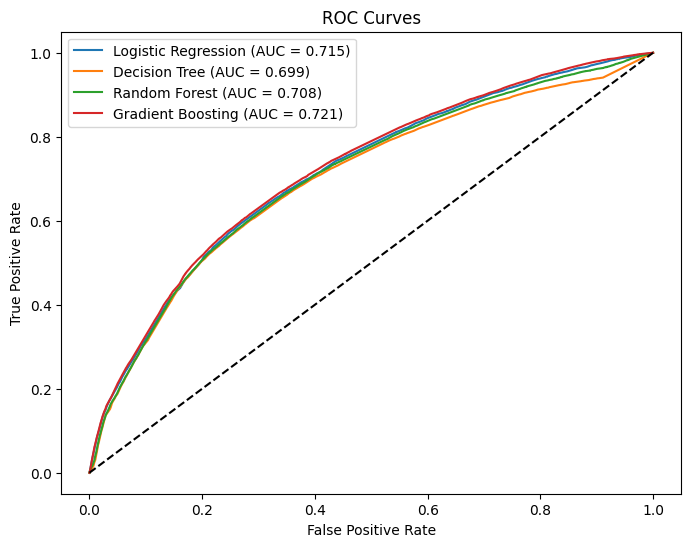

In [196]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
lst_auc = []

for name, pipe in pipelines.items(): 
    if hasattr(pipe["model"], "predict_proba"):
        y_score = pipe.predict_proba(X_test)[:,1]
    elif hasattr(pipe["model"], "decision_function"):
        y_score = pipe.decision_function(X_test)
    else:
        # fallback: just use predictions (not ideal for ROC, but works)
        y_score = model.predict(X_test)
        print(f"Warning: {name} does not have predict_proba or decision_function, using predict()")

    fpr, tpr, _ = roc_curve(y_test, y_score)
    auc_score = auc(fpr, tpr)
    lst_auc.append((name, auc_score))

    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.3f})")
    print(f"AUC of {name}: {auc_score:.3f}")

plt.plot([0,1],[0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()

In [197]:
# Finally we are going to save the dataset cleaned
df_lieux.to_csv("df_lieux_clean.csv", index=False)

In [198]:
df_lieux = pandas.read_csv("df_lieux_clean.csv")

In [199]:
print("All columns:", df_lieux.columns)
print("Features:", features)

All columns: Index(['Num_Acc', 'catr', 'circ', 'nbv', 'vosp', 'prof', 'plan', 'surf',
       'infra', 'situ', 'vma'],
      dtype='str')
Features: ['catr', 'circ', 'nbv', 'vosp', 'prof', 'plan', 'surf', 'infra', 'situ', 'vma']
